In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re
from pathlib import Path
import polarity.utilities.figure_helper as fh

### Select setup

In [2]:
# One of: "base", "bd" (basal dominant), or "ls" (late secretory)
system = "base"
matlab_directory = Path("../matlab/")

match system:
    case "base":
        filename_pattern = re.compile(r"^(?!.*(?:bd|ls)).*$") # Ignore anything containing ls or bd
        file_suffix = ""
    case "bd":
        filename_pattern = re.compile(r"^(?=.*bd).*$") # Only include files containing bd
        file_suffix = "-bd"
    case "ls":
        filename_pattern = re.compile(r"^(?=.*ls).*$") # Only include files containing ls
        file_suffix = "-ls"
    case _:
        raise ValueError(f"Unknown system: {system}")

In [3]:
# Read in all the data files in ../matlab/*.txt as csv files and store in a dictionary with the filename as the key and the dataframe as the value
data_files = matlab_directory.glob("*.txt")
data_dict = {}
for file in data_files:
    if filename_pattern.match(file.name):
        file_key = Path(file).stem.replace("_data", "").replace("_" + system, "")
        print(f"Reading in {file} as {file_key}")
        df = pd.read_csv(file, sep=',')
        # # Add a column to segment the data for plotting (not actually needed anymore but keeping it for now)
        # df["segment"] = np.cumsum([1 if np.isnan(x) else 0 for x in df.M])
        data_dict[file_key] = df

Reading in ../matlab/nc_ra_data.txt as nc_ra
Reading in ../matlab/nc_rj_data.txt as nc_rj
Reading in ../matlab/steady_states.txt as steady_states
Reading in ../matlab/asym_jcyto_data.txt as asym_jcyto
Reading in ../matlab/asym_acyto_data.txt as asym_acyto


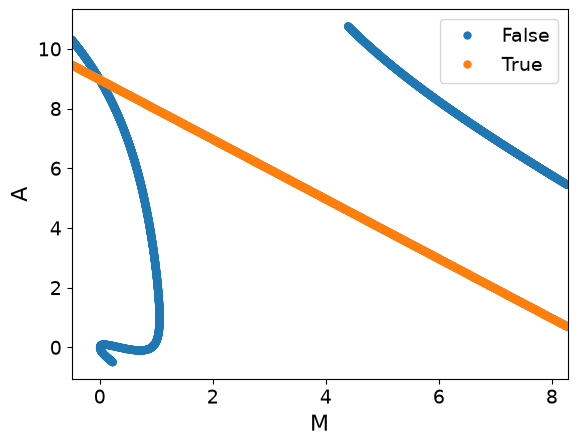

In [4]:
# Remove the asymptote lines from the other dataframes as fimplicit adds these
from polarity.models import par3nd as pm_nd

# Check the value of A_cyto ~ 0 by plotting
df = data_dict["nc_rj"]
tol = 5e-3
A_cyto_zero = np.isclose(df["A_cyto"], 0, atol=tol)
# sns.scatterplot(x='M', y='A', data=df[~A_cyto_zero], linewidth = 0)
sns.scatterplot(x='M', y='A', data=df, hue=A_cyto_zero, linewidth = 0)

# Based on these plots we remove the segments that have A_cyto ~ 0
for key in ["nc_rj", "asym_jcyto"]:
    df = data_dict[key]
    data_dict[key] = df[~np.isclose(df["A_cyto"], 0, atol=tol)]

In [5]:
# Define the style mappings
# For the nullclines
style_mapping = {
    "nc_ra": {"label": "$R_A=0$", "color": fh.colours_map["A"], "linestyle": "-"},
    "nc_rj": {"label": "$R_J=0$", "color": fh.colours_map["J"], "linestyle": "-"}
}
# And for the stability markers
stability_markers_legend = {"stable": "o", "unstable": "$\\circ$"}

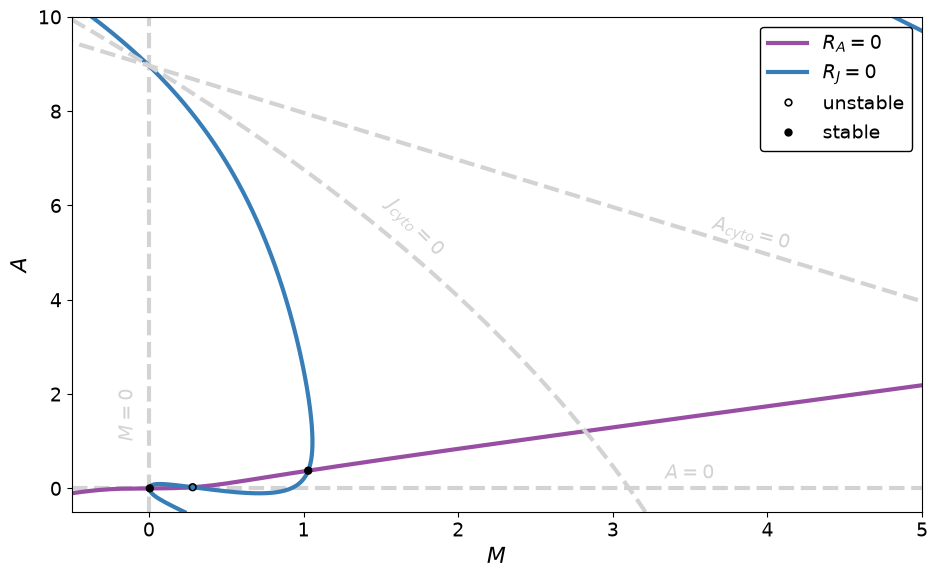

In [6]:
# Plot the full region of interest

# Need to calculate M_max and A_max
from unittest import case


psi, rho_A = 0.174, 1.56
M_max = rho_A/psi

# Initialise plot in domain of interest
fig = plt.figure()
fig.set_size_inches(0.8*fh.page_width_fig, 6)

asymptote_colour = "lightgray"

# Lines at M=0, A=0, and M=M_max
plt.axhline(0, color=asymptote_colour, linestyle='--')
plt.text(3.5, 0.1, "$A=0$", color=asymptote_colour, fontsize=fh.label_font_size, ha='center', va='bottom')
plt.axvline(0, color=asymptote_colour, linestyle='--')
plt.text(-0.2, 1, "$M=0$", color=asymptote_colour, fontsize=fh.label_font_size, rotation = 90, va='bottom')

# Add the data from matlab
for key, df in data_dict.items():
    if key != "steady_states": # Steady states are treated differently
        style = style_mapping.get(key, {"label": None, "color": asymptote_colour, "linestyle": "--"}) # Default to gray dashed lines if key not found
        plt.plot(df['M'], df['A'], label=style["label"], color=style["color"], linestyle=style["linestyle"])

# Add labels for the asymptote lines
plt.text(np.mean(data_dict["asym_acyto"]['M']), np.mean(data_dict["asym_acyto"]['A']), 
         "$A_{cyto}=0$", color=asymptote_colour, fontsize=fh.label_font_size, ha='center', rotation=-15)
plt.text(1.1*np.mean(data_dict["asym_jcyto"]['M']), np.mean(data_dict["asym_jcyto"]['A']), 
         "$J_{cyto}=0$", color=asymptote_colour, fontsize=fh.label_font_size, ha='center', rotation=-45)

# Plot the steady states as a scatter plot with black color and label "steady_states"
sns.scatterplot(x='M', y='A', data=data_dict["steady_states"], style='stability', 
                markers=stability_markers_legend, linewidth=0, zorder=4, 
                # color = "white")
                color="k")

# Formatting
plt.tight_layout()
plt.xlabel('$M$')
plt.ylabel('$A$')
plt.legend(framealpha = 1, fontsize=fh.label_font_size, edgecolor = "k")
if system == "base":
    plt.xlim(-0.5, 5)
    plt.ylim(-0.5, 10)
else:
    plt.xlim(-0.5, 4)
    plt.ylim(-0.5, 5)

plt.show()

fig.savefig(fh.FIGURES_DIR / f"nullclines_full{file_suffix}.pdf")

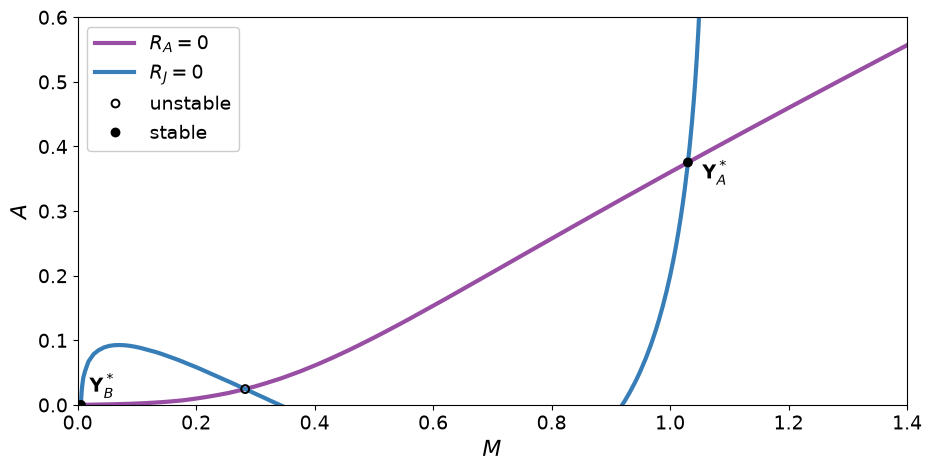

In [7]:
# Plot the subregion of interest around the steady states
if system == "base":
    fig = plt.figure(figsize=(0.8*fh.page_width_fig, 5))
    plt.xlim(0, 1.4)
    plt.ylim(0, 0.6)
else:
    fig = plt.figure(figsize=(0.6*fh.page_width_fig, 5))
    plt.xlim(0, 1.0)
    plt.ylim(-0.1, 0.6)
    # Add a horizontal line at A=0
    plt.axhline(0, color="black", linewidth = 1)

# Add the nullcline data from matlab
for key in ["nc_ra", "nc_rj"]: 
    df = data_dict[key]
    style = style_mapping.get(key, {"label": None, "color": "gray", "linestyle": "--"}) # Default to gray dashed lines if key not found
    plt.plot(df['M'], df['A'], label=style["label"], color=style["color"], linestyle=style["linestyle"])
    
# Plot the steady states as a scatter plot with black color and label "steady_states"
sns.scatterplot(x='M', y='A', data=data_dict["steady_states"], style='stability', 
                markers=stability_markers_legend, zorder=4, color="k", linewidth=0, s=50)

# Add annotations to the stable steady state points
# Basally daominant steady state
if system != "ls":
    plt.text(0.02, 0.02, '$\\mathbf{Y}^*_B$', color='black', fontsize=fh.label_font_size)
# Apically-dominant steady state
if system == "base":
    plt.text(1.1, 0.35, '$\\mathbf{Y}^*_A$', color='black', fontsize=fh.label_font_size, ha = "right")
elif system == "ls":
    plt.text(0.85, 0.3, '$\\mathbf{Y}^*_A$', color='black', fontsize=fh.label_font_size, ha = "right")

# Formatting
plt.tight_layout()
plt.xlabel('$M$')
plt.ylabel('$A$')
plt.legend(framealpha=1, fontsize=fh.label_font_size)
plt.show()

fig.savefig(fh.FIGURES_DIR / f"nullclines_subregion{file_suffix}.pdf")

In [32]:
data_dict["steady_states"].sort_values(by=["M", "A"], inplace=True, ignore_index=True)
# print(data_dict["steady_states"])
for Y in data_dict["steady_states"].itertuples():
    print(f"Steady state {Y.Index + 1} ({Y.stability})")
    print(f"Y^*_{Y.Index + 1} =(J = {Y.J:.3g}, M={Y.M:.3g}, A={Y.A:.3g}, P = {Y.P:.3g})")
    print(f"lambda_{Y.Index + 1} = ({Y.eigenvalues_1:.3g}, {Y.eigenvalues_2:.3g}, {Y.eigenvalues_3:.3g}, {Y.eigenvalues_4:.3g})")

Steady state 1 (stable)
Y^*_1 =(J = 0.0699, M=0.00562, A=4.55e-05, P = 3.04)
lambda_1 = (-0.0153, -0.157, -0.24, -0.319)
Steady state 2 (unstable)
Y^*_2 =(J = 0.491, M=0.283, A=0.0245, P = 0.232)
lambda_2 = (-0.224, 0.0129, -0.0471, -0.0321)
Steady state 3 (stable)
Y^*_3 =(J = 1.02, M=1.03, A=0.375, P = 0.012)
lambda_3 = (-3.97, -0.0193, -0.00994, -0.00482)
Steady state 4 (unstable)
Y^*_4 =(J = -14.5, M=9.42, A=4.15, P = 0.000129)
lambda_4 = (-368, 0.02, -0.00884, -0.0054)
